###
<h1><strong> Task 2: Exploratory Data Analysis (EDA)</strong></h1>

Description: Perform an exploratory analysis on a
given dataset to identify patterns, trends, and
summary statistics.

<h3><strong> Objectives:</strong></h3> 
<ul>
    <li>Calculate summary statistics (mean, median, mode,standard deviation).</li>
    <li>Visualize data distributions using histograms, boxplots,and scatter plots.</li>
    <li>Find correlations between numerical features.</li>
</ul>
<p>
Tools: Python, pandas, matplotlib,
seaborn.</p>




<h1>----------------------------------------------------------------------------------------------</h1>

In [1]:
import sys
import importlib
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))



CLEAN_DIR = PROJECT_ROOT / "data/cleaned_data"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {PROJECT_ROOT}")
print(f"Cleaned files : {len(list(CLEAN_DIR.rglob('*.csv')))}")

Projet : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis
Cleaned files : 5


<h4>The dataset: Stock prices</h4>
<p>
    <h4><strong><li>Summary statistics (mean, median, mode, standard deviation)</li></strong></h4>
</p>

In [2]:
c_stock = pd.read_csv(CLEAN_DIR / "c_stock.csv")

In [ ]:
# Select numerical columns
numeric_columns = c_stock.select_dtypes(include="number").columns

# Calculate summary statistics
summary_statistics = pd.DataFrame({
    "mean": c_stock[numeric_columns].mean(),
    "median": c_stock[numeric_columns].median(),
    "mode": c_stock[numeric_columns].mode().iloc[0],
    "standard_deviation": c_stock[numeric_columns].std()
})

summary_statistics

,mean,median,mode,standard_deviation
open,8.635199e+01,64.97,70.0,1.014704e+02
high,8.713388e+01,65.56,72.0,1.023133e+02
low,8.555156e+01,64.35,77.0,1.005704e+02
close,8.636908e+01,64.98,34.5,1.014724e+02
volume,4.253611e+06,2084896.50,1241019.0,8.232139e+06


<h4><li><strong><p>Data visualization </p></strong></li></h4>

<p><strong> 1-Histograms:</strong>
groups numerical values into ranges and counts how many values fall into each range. <br>

-X-axis: numerical value ranges, called bins <br>
-Y-axis: frequency or number of observations in each range <br>
</p>

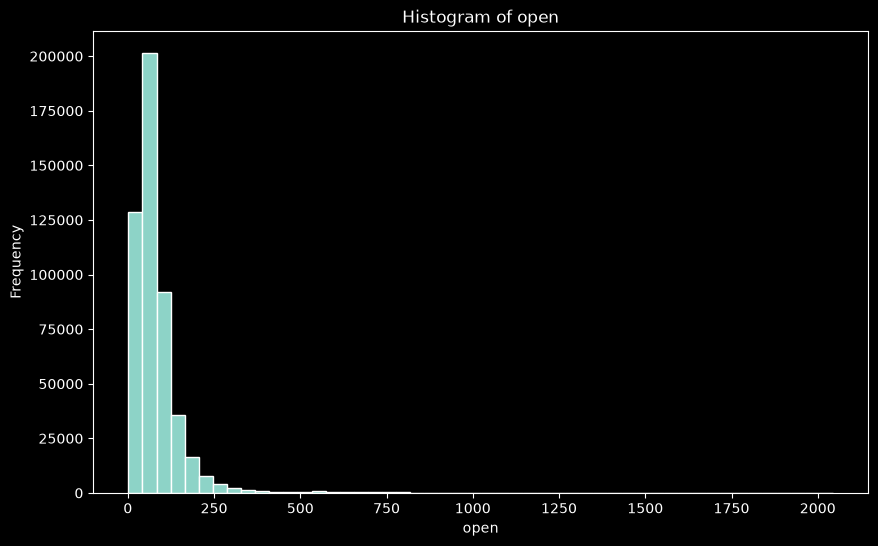

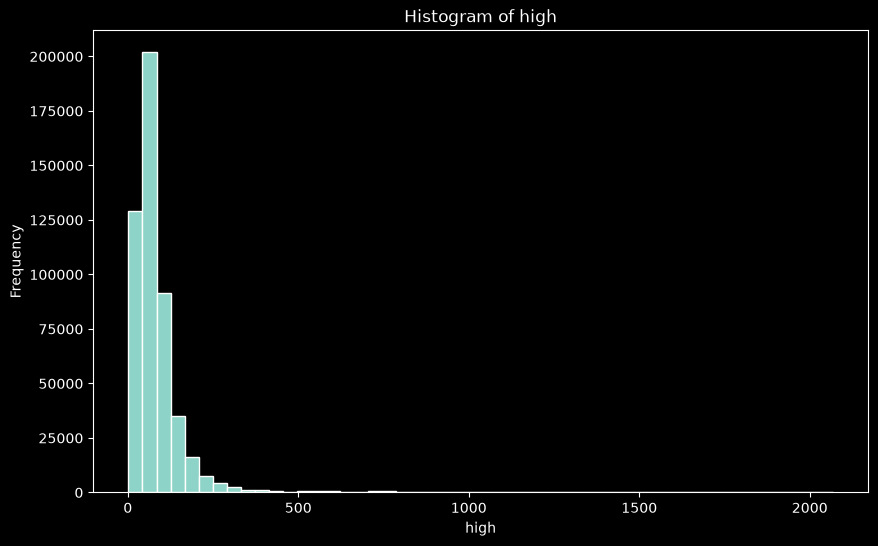

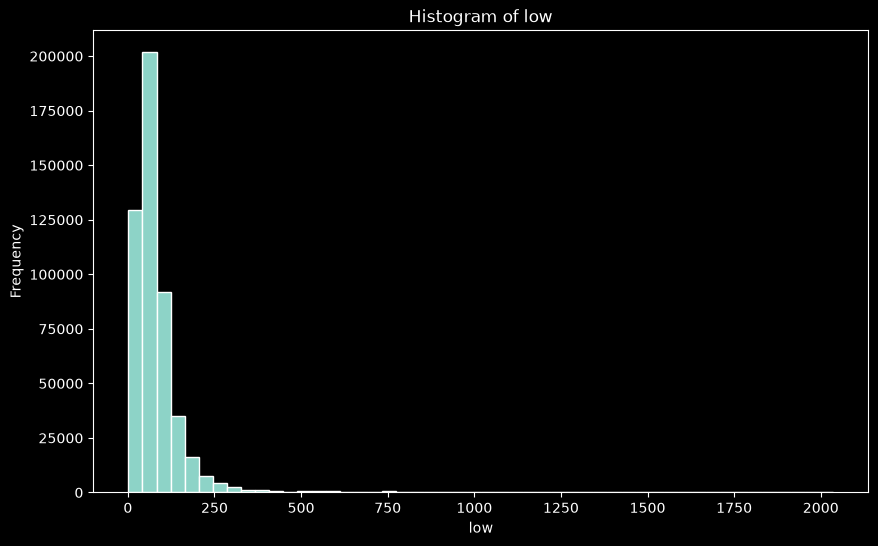

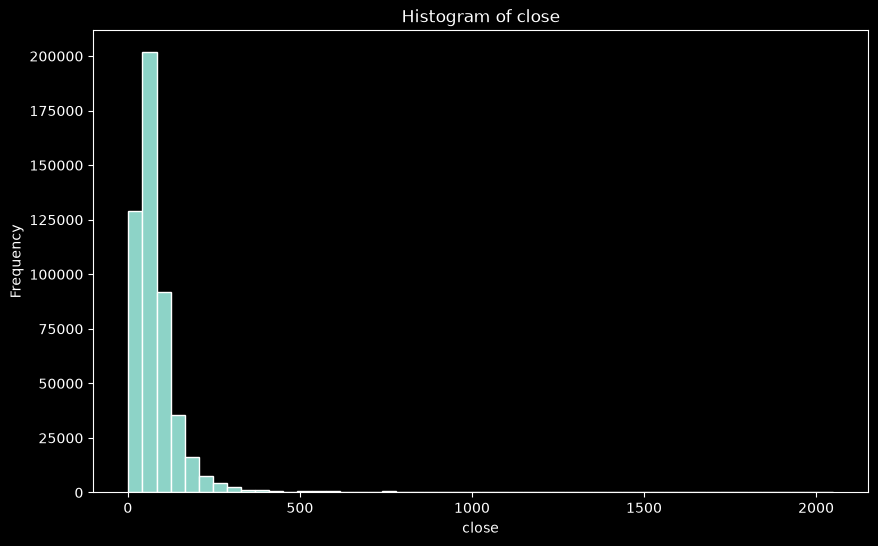

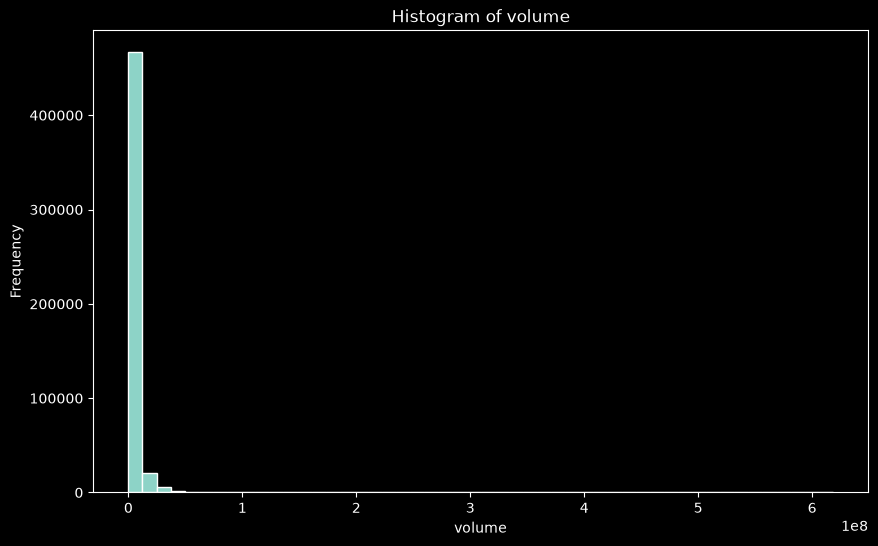

In [ ]:
#Histograms for numerical columns
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    plt.hist(c_stock[col], bins=50, edgecolor='white')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

<p><strong> 2- Boxplots</strong>
summarizes the distribution of numerical data and helps identify outliers.

It shows:

-Middle line: median (50%) <br>
-Bottom of box: first quartile (25%)<br>
-Top of box: third quartile (75%)<br>
-Box height: interquartile range, 𝐼𝑄𝑅=𝑄3−𝑄1<br>
-Whiskers: typical minimum and maximum values<br>
-Points beyond whiskers: possible outliers<br>
</p>

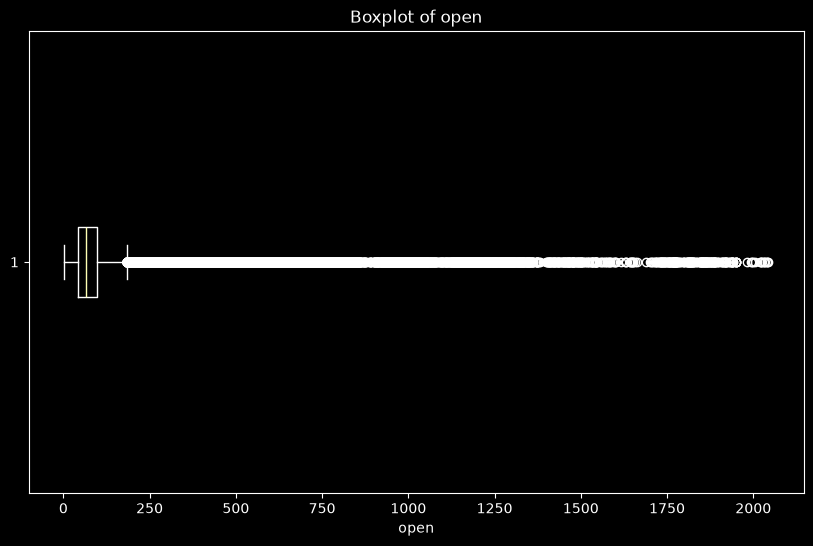

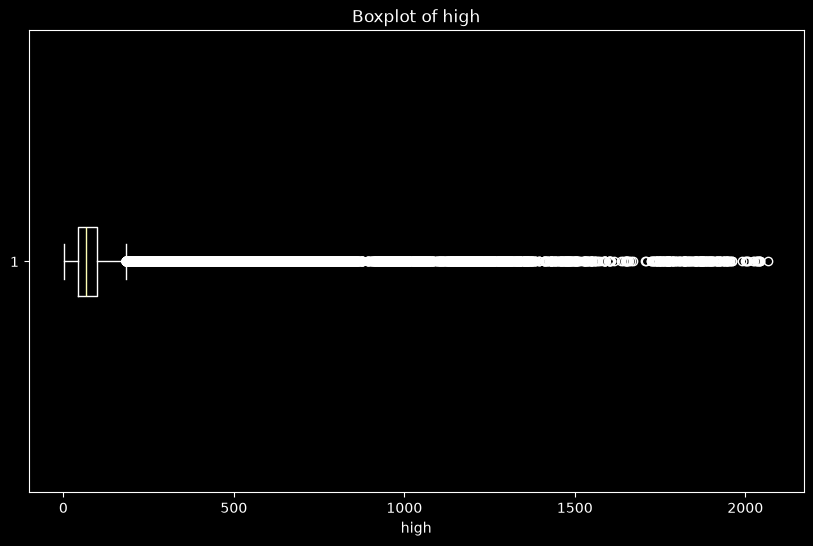

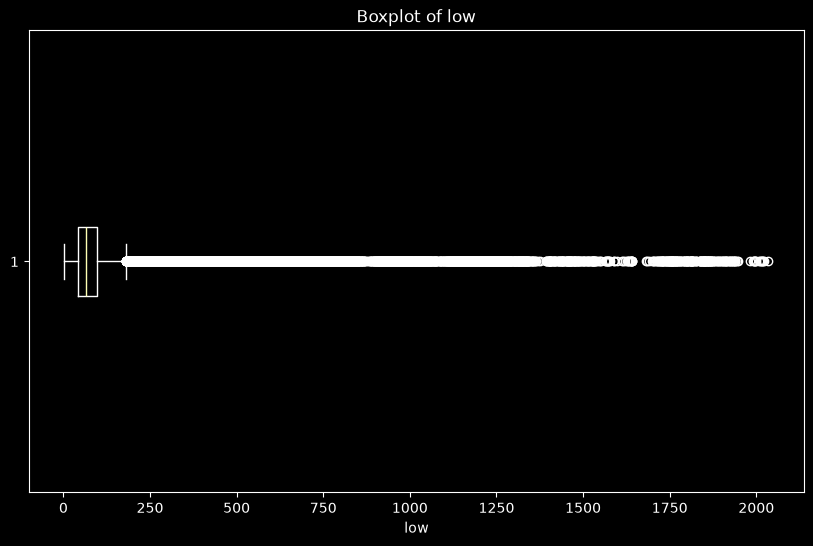

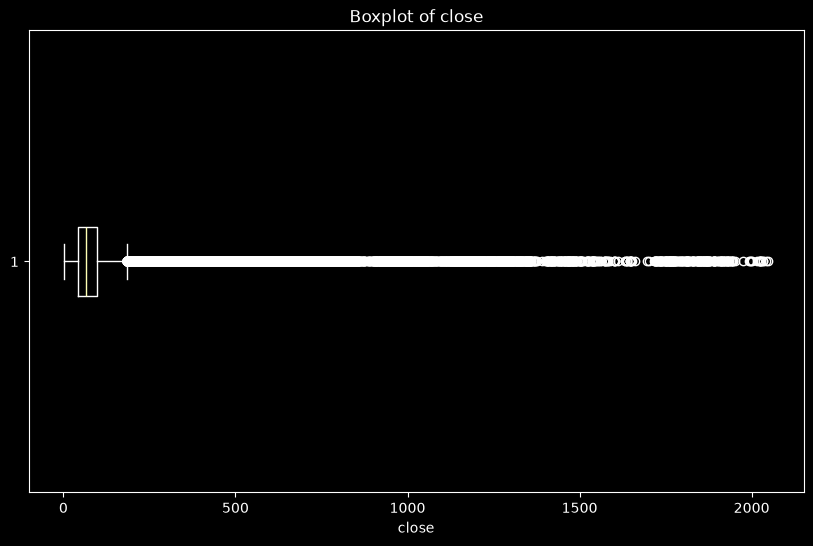

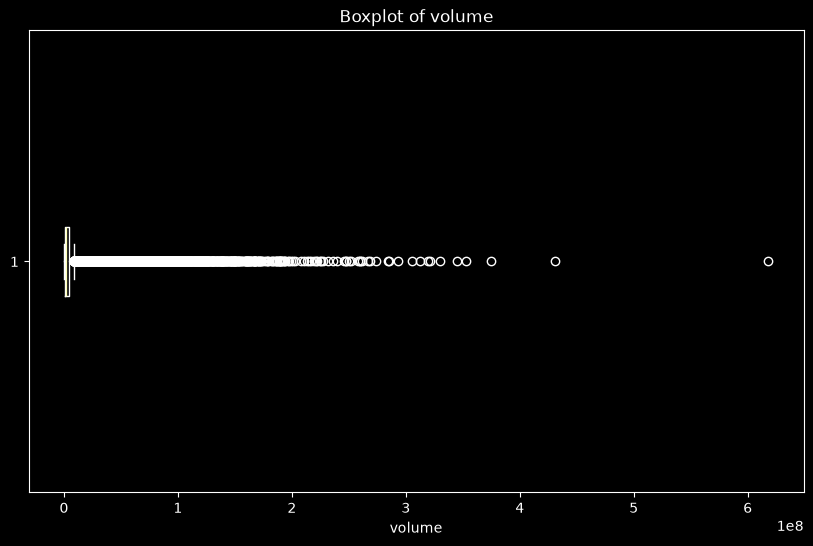

In [ ]:
#Boxplots for numerical columns
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    plt.boxplot(c_stock[col],orientation='horizontal')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

<p><strong>3. Scatter plots: </strong>mainly used to compare two numerical variables.</p>

Interpretation:

<p>
    <ul>
        <li>
            Points close to a diagonal line suggest that open and close move together.
        </li>
        <li>
            An upward pattern indicates a positive relationship.
        </li>
        <li>
            Isolated points may be outliers.
        </li>
        <li>
            A random cloud of points suggests a weak relationship.
        </li>
    </ul>
</p>





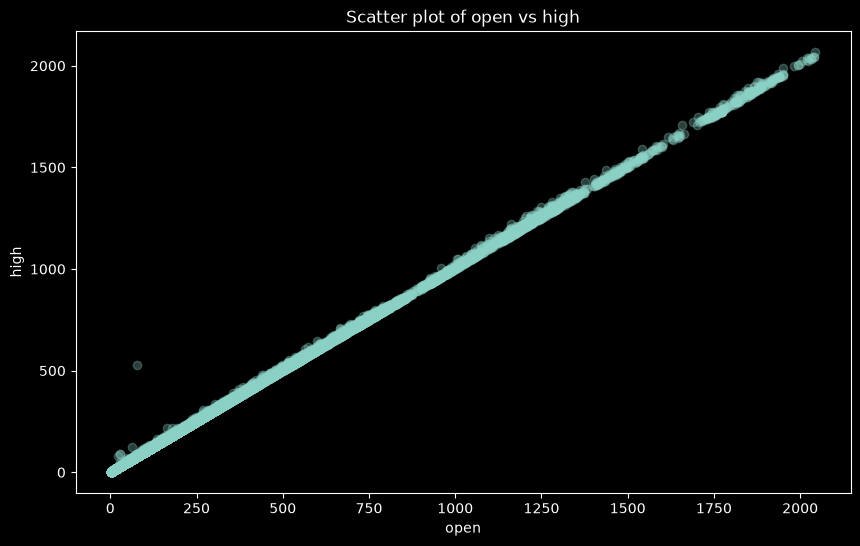

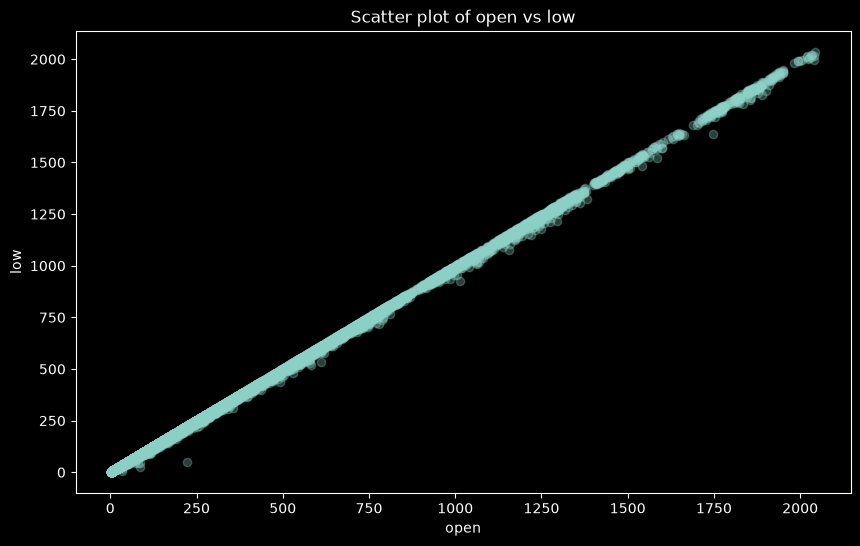

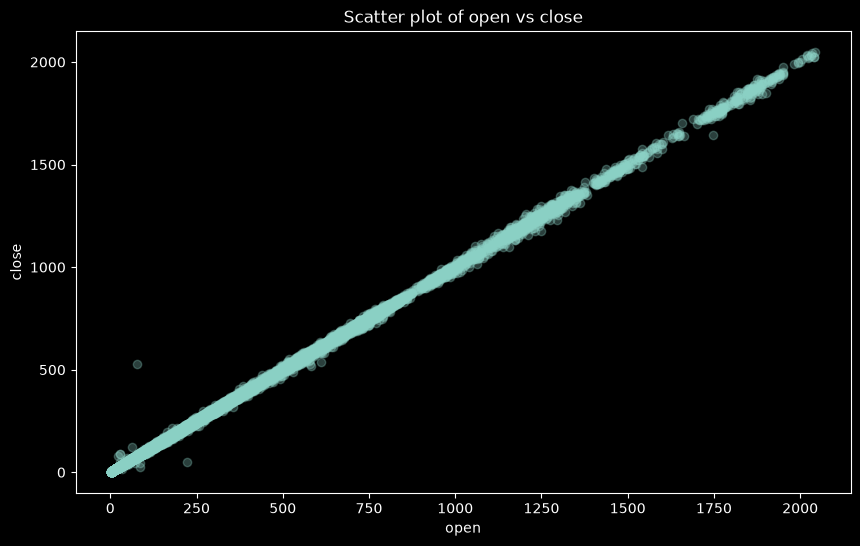

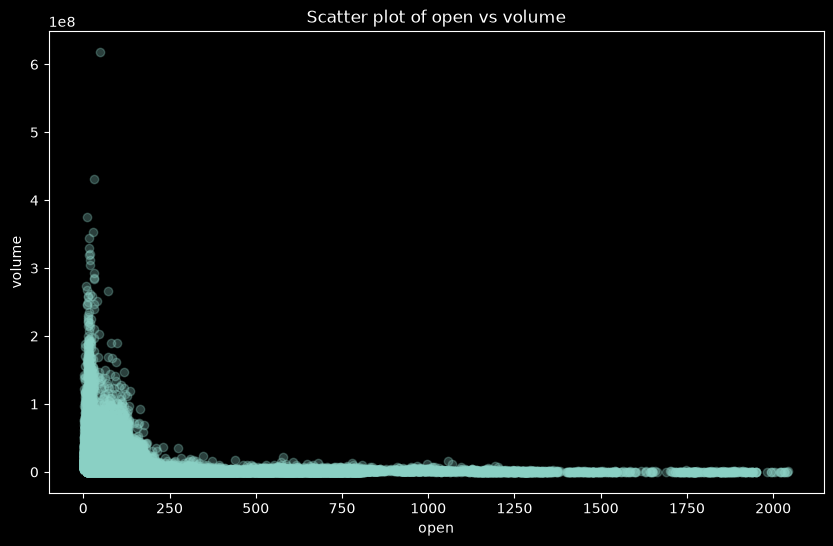

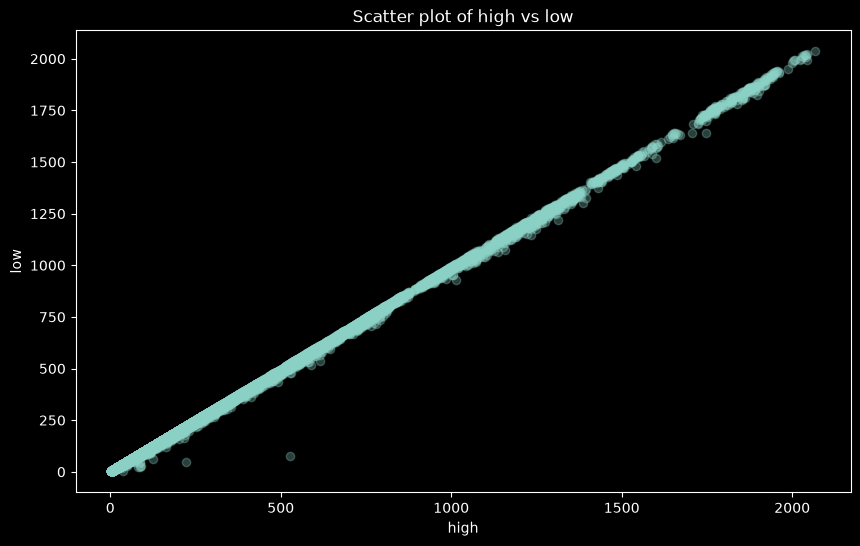

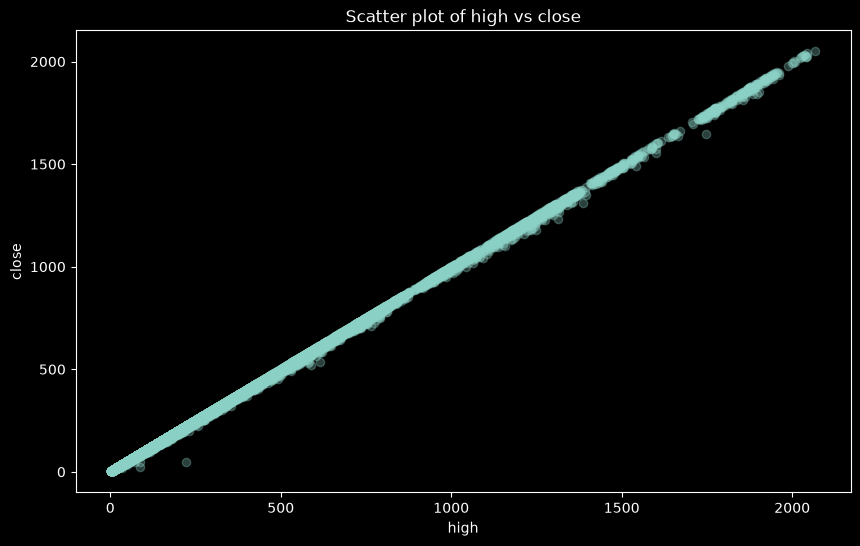

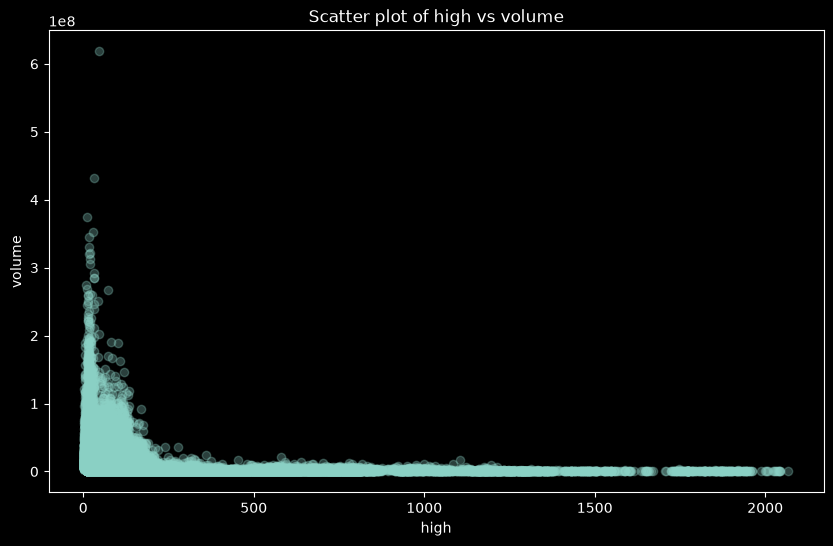

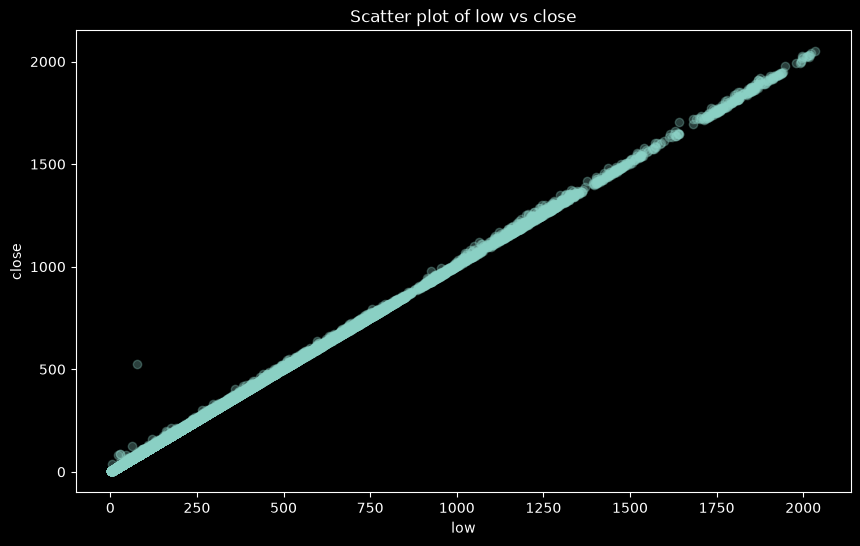

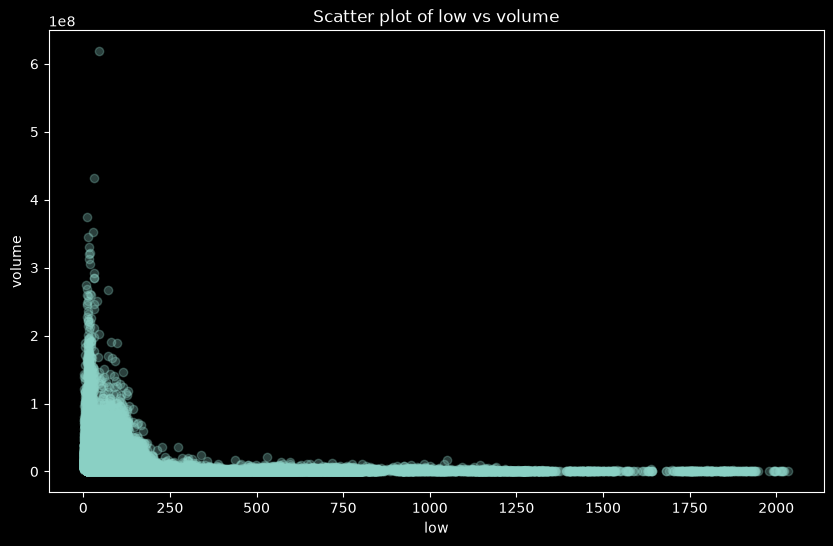

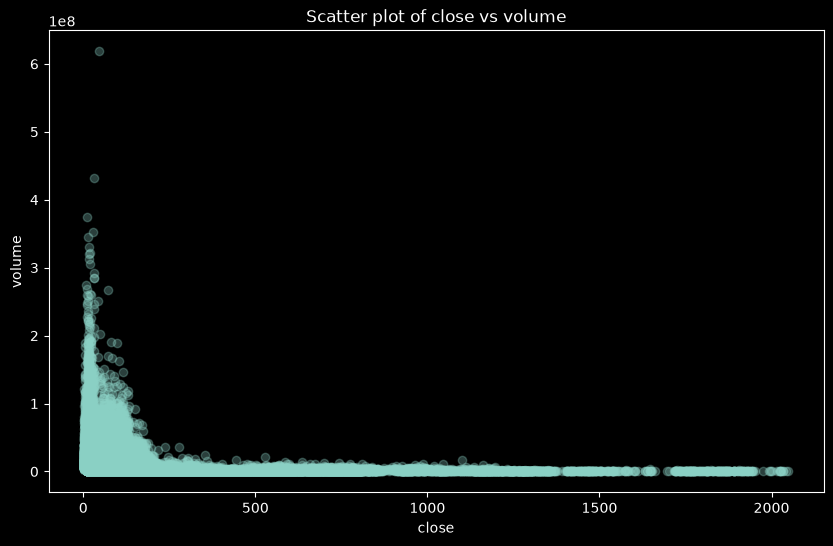

In [ ]:
#Scatter plots for numerical columns
for i in range(len(numeric_columns)):
    for j in range(i + 1, len(numeric_columns)):
        plt.figure(figsize=(10, 6))
        plt.scatter(c_stock[numeric_columns[i]], c_stock[numeric_columns[j]], alpha=0.3)
        plt.title(f'Scatter plot of {numeric_columns[i]} vs {numeric_columns[j]}')
        plt.xlabel(numeric_columns[i])
        plt.ylabel(numeric_columns[j])
        plt.show()

#Or i can use the statement below
#sns.pairplot(c_stock)

<h4><li><strong>Correlation between numerical features</strong>: measures how two numerical columns vary together but does not prove that one variable causes the other</li></h4>
<p>Correlation asks:<br>When a given value increases, does the other one usually increase too?</p>

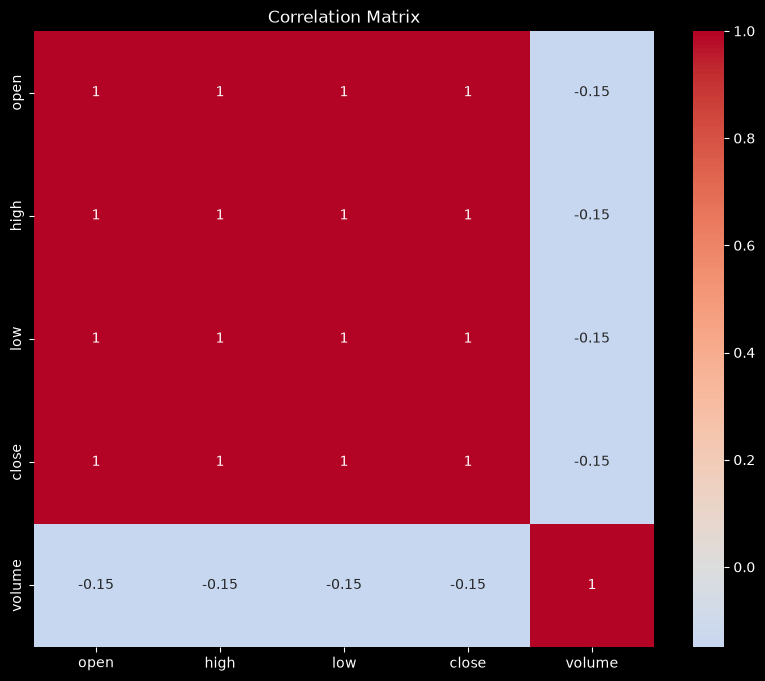

In [ ]:
#Correlation between numerical features using seaborn heatmap
correlation_matrix = c_stock[numeric_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

<h1